RFM KPI Summary

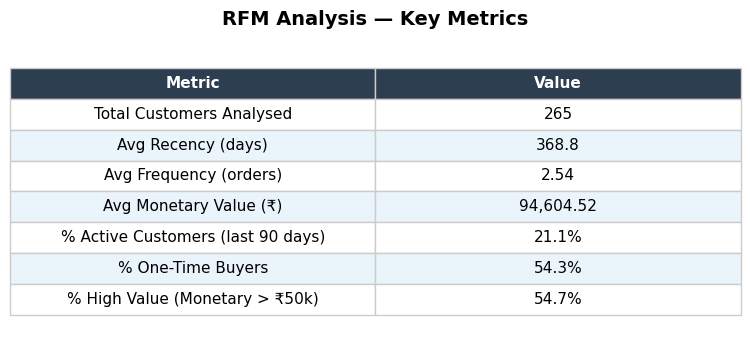


── Raw KPI Values ──
  Total Customers Analysed                     : 265
  Avg Recency (days)                           : 368.8
  Avg Frequency (orders)                       : 2.54
  Avg Monetary Value (₹)                       : 94,604.52
  % Active Customers (last 90 days)            : 21.1%
  % One-Time Buyers                            : 54.3%
  % High Value (Monetary > ₹50k)               : 54.7%


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load master datasets ──────────────────────────────────────────────────────
orders   = pd.read_csv(r"cleaned_data\orders_clean.csv")
payments = pd.read_csv(r"cleaned_data\payments_clean.csv")
customers = pd.read_csv(r"cleaned_data\customers_clean.csv")

# ── Parse dates ──────────────────────────────────────────────────────────────
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'], format='mixed')

delivered = orders[orders['order_status'] == 'delivered'].copy()
df = (delivered
      .merge(payments,  on='order_id',   how='inner')
      .merge(customers, on='customer_id', how='inner'))

reference_date = df['order_purchase_timestamp'].max()

rfm_raw = (df.groupby('customer_id')
             .agg(last_order=('order_purchase_timestamp', 'max'),
                  Frequency=('order_id', 'count'),
                  Monetary=('payment_value', 'sum'))
             .reset_index())
rfm_raw['Recency'] = (reference_date - rfm_raw['last_order']).dt.days

total_customers = len(rfm_raw)
avg_recency     = rfm_raw['Recency'].mean()
avg_frequency   = rfm_raw['Frequency'].mean()
avg_monetary    = rfm_raw['Monetary'].mean()
pct_active      = (rfm_raw['Recency'] <= 90).mean() * 100
pct_one_time    = (rfm_raw['Frequency'] == 1).mean() * 100
pct_high_value  = (rfm_raw['Monetary'] > 50000).mean() * 100

kpis = [
    ('Total Customers Analysed',           f'{total_customers:,}'),
    ('Avg Recency (days)',                  f'{avg_recency:.1f}'),
    ('Avg Frequency (orders)',              f'{avg_frequency:.2f}'),
    ('Avg Monetary Value (₹)',         f'{avg_monetary:,.2f}'),
    ('% Active Customers (last 90 days)',   f'{pct_active:.1f}%'),
    ('% One-Time Buyers',                   f'{pct_one_time:.1f}%'),
    ('% High Value (Monetary > ₹50k)', f'{pct_high_value:.1f}%'),
]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis('off')
tbl = ax.table(cellText=kpis, colLabels=['Metric', 'Value'],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.8)
row_colors = ['#ffffff', '#eaf4fb']
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors[(row - 1) % 2])
    cell.set_edgecolor('#cccccc')
ax.set_title('RFM Analysis — Key Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n── Raw KPI Values ──")
for label, val in kpis:
    print(f"  {label:45s}: {val}")

RFM Score Calculation

In [52]:
orders   = pd.read_csv(r"cleaned_data\orders_clean.csv")
payments = pd.read_csv(r"cleaned_data\payments_clean.csv")
customers = pd.read_csv(r"cleaned_data\customers_clean.csv")

orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp'], format='mixed')

delivered = orders[orders['order_status'] == 'delivered'].copy()
df = (delivered
      .merge(payments,  on='order_id',   how='inner')
      .merge(customers, on='customer_id', how='inner'))

reference_date = df['order_purchase_timestamp'].max()

rfm = (df.groupby('customer_id')
         .agg(last_order=('order_purchase_timestamp', 'max'),
              Frequency=('order_id', 'nunique'),
              Monetary=('payment_value', 'sum'))
         .reset_index())
rfm['Recency'] = (reference_date - rfm['last_order']).dt.days

# ── Robust 1-5 scoring (handles tied values & small datasets) ─────────────────
def score_series(s, n=5, reverse=False):
    """Uses rank(method='first') to break ties before cutting into equal bins.
    Avoids ValueError from pd.qcut when duplicate bin edges exist."""
    ranks = s.rank(method='first', ascending=not reverse)
    return pd.cut(ranks, bins=n, labels=range(1, n+1),
                  include_lowest=True).astype(int)

rfm['R_score'] = score_series(rfm['Recency'],   reverse=True)   # lower days = higher score
rfm['F_score'] = score_series(rfm['Frequency'], reverse=False)
rfm['M_score'] = score_series(rfm['Monetary'],  reverse=False)

rfm['RFM_Score'] = (rfm['R_score'].astype(str)
                    + rfm['F_score'].astype(str)
                    + rfm['M_score'].astype(str))
rfm['RFM_Total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

cust_info = customers[['customer_id', 'customer_name', 'customer_city', 'customer_state']]
rfm = rfm.merge(cust_info, on='customer_id', how='left')

rfm_df = rfm.copy()   # global — used by all later sections

print(f"RFM table shape : {rfm_df.shape}")
print(f"Columns         : {rfm_df.columns.tolist()}")
print("\n── Top 10 by RFM_Total ──")
print(rfm_df.nlargest(10, 'RFM_Total')[
    ['customer_name','customer_state','Recency','Frequency','Monetary',
     'R_score','F_score','M_score','RFM_Total']
].to_string(index=False))
print("\n── Score Distributions ──")
for col in ['R_score','F_score','M_score']:
    print(f"  {col}: {rfm_df[col].value_counts().sort_index().to_dict()}")
print("\n── First 10 rows ──")
print(rfm_df.head(10).to_string(index=False))

RFM table shape : (265, 13)
Columns         : ['customer_id', 'last_order', 'Frequency', 'Monetary', 'Recency', 'R_score', 'F_score', 'M_score', 'RFM_Score', 'RFM_Total', 'customer_name', 'customer_city', 'customer_state']

── Top 10 by RFM_Total ──
 customer_name customer_state  Recency  Frequency  Monetary  R_score  F_score  M_score  RFM_Total
  Rahul Saxena      Rajasthan       13         10 291020.27        5        5        5         15
   Deepak Shah     Tamil Nadu       41          5 219959.04        5        5        5         15
    Rahul Shah      Karnataka       14          5 167160.48        5        5        5         15
  Pankaj Gupta          Delhi       40         10 631471.76        5        5        5         15
Meera Malhotra    Maharashtra       22         11 407203.54        5        5        5         15
  Tarun Sharma      Telangana       66         10 331845.96        5        5        5         15
  Sanjay Singh         Punjab       77          8 338392.51     

RFM Score Calculation

In [53]:
def assign_segment(row):
    R, F = row['R_score'], row['F_score']
    if   R == 5 and F >= 4:  return 'Champions'
    elif F >= 4 and R >= 3:  return 'Loyal Customers'
    elif R >= 3 and F == 3:  return 'Potential Loyal'
    elif R == 5 and F <= 2:  return 'New Customers'
    elif R == 4 and F <= 2:  return 'Promising'
    elif R == 3 and F <= 3:  return 'Need Attention'
    elif R == 2 and F <= 3:  return 'About to Sleep'
    elif R <= 2 and F >= 3:  return 'At Risk'
    elif R == 1 and F >= 4:  return 'Cannot Lose Them'
    elif R <= 2 and F <= 2:  return 'Hibernating'
    else:                    return 'Lost'

rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)

seg_summary = (rfm_df.groupby('Segment')
                     .size()
                     .reset_index(name='Count')
                     .assign(Pct=lambda x: (x['Count']/x['Count'].sum()*100).round(2))
                     .sort_values('Count', ascending=False))
print("── Segment Distribution ──")
print(seg_summary.to_string(index=False))

── Segment Distribution ──
        Segment  Count   Pct
Loyal Customers     50 18.87
 About to Sleep     38 14.34
    Hibernating     37 13.96
      Champions     34 12.83
        At Risk     31 11.70
Potential Loyal     27 10.19
 Need Attention     22  8.30
      Promising     14  5.28
  New Customers     12  4.53


Assigning Customer Segments

In [54]:
def assign_segment(row):
    R, F = row['R_score'], row['F_score']
    if   R == 5 and F >= 4:                  return 'Champions'
    elif F >= 4 and R >= 3:                  return 'Loyal Customers'
    elif R >= 3 and F == 3:                  return 'Potential Loyal'
    elif R == 5 and F <= 2:                  return 'New Customers'
    elif R == 4 and F <= 2:                  return 'Promising'
    elif R == 3 and F <= 3:                  return 'Need Attention'
    elif R == 2 and F <= 3:                  return 'About to Sleep'
    elif R <= 2 and F >= 3:                  return 'At Risk'
    elif R == 1 and F >= 4:                  return 'Cannot Lose Them'
    elif R <= 2 and F <= 2:                  return 'Hibernating'
    elif R == 1 and F == 1:                  return 'Lost'
    else:                                    return 'Hibernating'

rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)

seg_summary = (rfm_df.groupby('Segment')
                     .size()
                     .reset_index(name='Count')
                     .assign(Pct=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2))
                     .sort_values('Count', ascending=False))

print("── Segment Distribution ──")
print(seg_summary.to_string(index=False))

── Segment Distribution ──
        Segment  Count   Pct
Loyal Customers     50 18.87
 About to Sleep     38 14.34
    Hibernating     37 13.96
      Champions     34 12.83
        At Risk     31 11.70
Potential Loyal     27 10.19
 Need Attention     22  8.30
      Promising     14  5.28
  New Customers     12  4.53


Segment Distribution Visualization

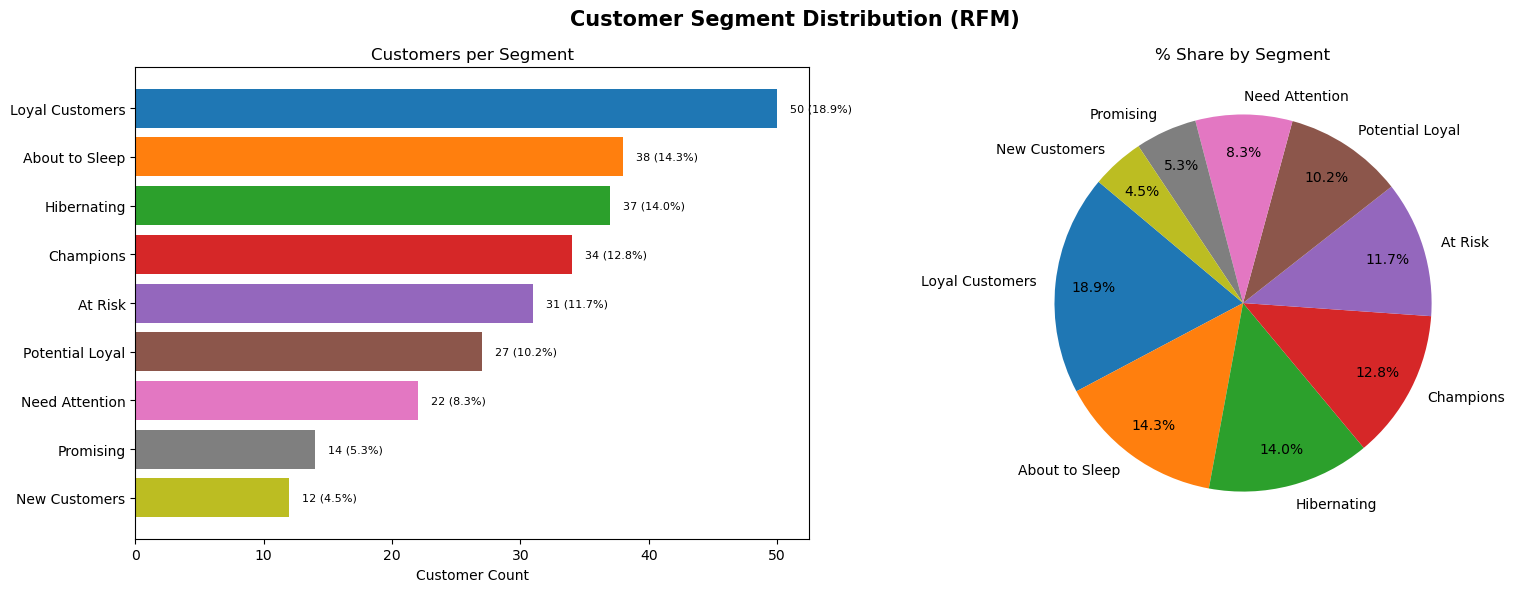


── Segment Summary ──
        Segment  Count       Pct
Loyal Customers     50 18.867925
 About to Sleep     38 14.339623
    Hibernating     37 13.962264
      Champions     34 12.830189
        At Risk     31 11.698113
Potential Loyal     27 10.188679
 Need Attention     22  8.301887
      Promising     14  5.283019
  New Customers     12  4.528302


In [55]:
seg_counts = (rfm_df.groupby('Segment')
                    .size().reset_index(name='Count')
                    .sort_values('Count', ascending=False))
seg_counts['Pct'] = seg_counts['Count'] / seg_counts['Count'].sum() * 100

palette    = plt.cm.tab10.colors
seg_colors = {seg: palette[i % 10] for i, seg in enumerate(seg_counts['Segment'])}
colors     = [seg_colors[s] for s in seg_counts['Segment']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Segment Distribution (RFM)', fontsize=15, fontweight='bold')

ax1 = axes[0]
bars = ax1.barh(seg_counts['Segment'], seg_counts['Count'], color=colors)
ax1.invert_yaxis()
ax1.set_xlabel('Customer Count')
ax1.set_title('Customers per Segment')
for bar, (_, row) in zip(bars, seg_counts.iterrows()):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{int(row['Count']):,} ({row['Pct']:.1f}%)", va='center', fontsize=8)

axes[1].pie(seg_counts['Count'], labels=seg_counts['Segment'], colors=colors,
            autopct='%1.1f%%', pctdistance=0.80, startangle=140)
axes[1].set_title('% Share by Segment')

plt.tight_layout()
plt.show()
print("\n── Segment Summary ──")
print(seg_counts.to_string(index=False))

RFM Score Distribution


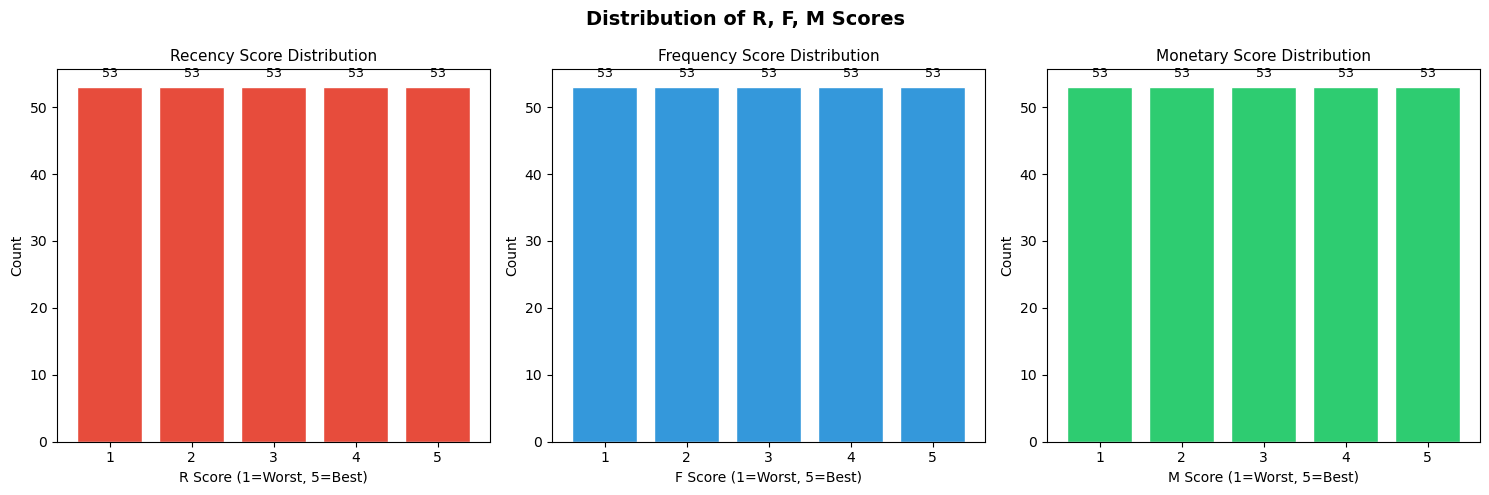


── R_score distribution ──
         Count
R_score       
1           53
2           53
3           53
4           53
5           53

── F_score distribution ──
         Count
F_score       
1           53
2           53
3           53
4           53
5           53

── M_score distribution ──
         Count
M_score       
1           53
2           53
3           53
4           53
5           53


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution of R, F, M Scores', fontsize=14, fontweight='bold')

configs = [
    ('R_score', '#e74c3c', 'Recency Score Distribution',   'R Score (1=Worst, 5=Best)'),
    ('F_score', '#3498db', 'Frequency Score Distribution', 'F Score (1=Worst, 5=Best)'),
    ('M_score', '#2ecc71', 'Monetary Score Distribution',  'M Score (1=Worst, 5=Best)'),
]
for ax, (col, color, title, xlabel) in zip(axes, configs):
    counts = rfm_df[col].value_counts().sort_index()
    bars   = ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_title(title, fontsize=11); ax.set_xlabel(xlabel); ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

for col in ['R_score','F_score','M_score']:
    print(f"\n── {col} distribution ──")
    print(rfm_df[col].value_counts().sort_index().rename('Count').to_frame())

Segment-wise RFM Comparison

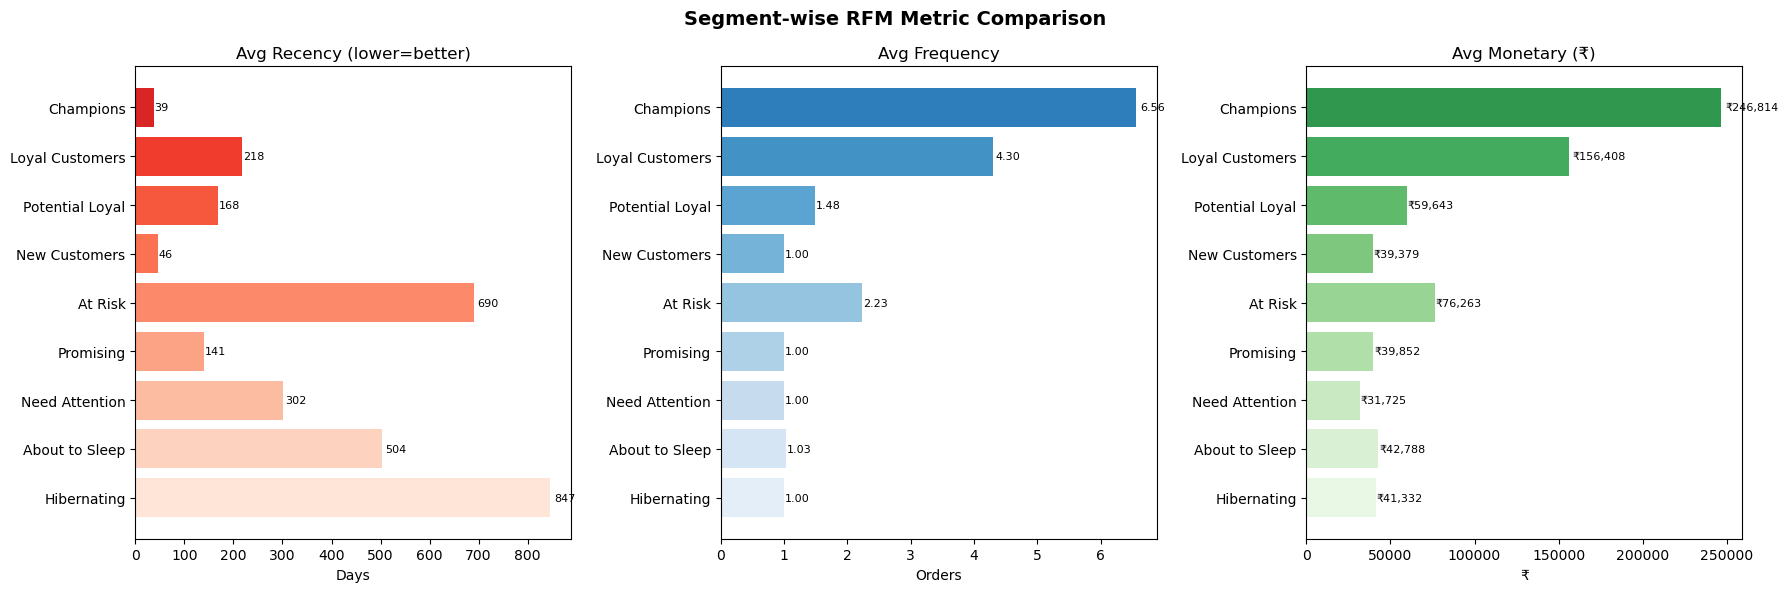


── Segment Metric Summary ──
        Segment  Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue_Cr  Avg_RFM_Total
      Champions              34    38.617647       6.558824 246813.538235          0.839166      14.323529
Loyal Customers              50   217.880000       4.300000 156407.725800          0.782039      12.260000
Potential Loyal              27   167.703704       1.481481  59642.821852          0.161036       9.518519
  New Customers              12    46.166667       1.000000  39379.421667          0.047255       8.583333
        At Risk              31   689.870968       2.225806  76262.729032          0.236414       8.322581
      Promising              14   140.642857       1.000000  39851.900714          0.055793       7.785714
 Need Attention              22   301.545455       1.000000  31724.936364          0.069795       6.454545
 About to Sleep              38   503.500000       1.026316  42788.097632          0.162595       6.236842
    Hib

In [57]:
seg_metrics = (rfm_df.groupby('Segment')
                     .agg(Customer_Count=('customer_id', 'count'),
                          Avg_Recency=('Recency', 'mean'),
                          Avg_Frequency=('Frequency', 'mean'),
                          Avg_Monetary=('Monetary', 'mean'),
                          Total_Revenue=('Monetary', 'sum'),
                          Avg_RFM_Total=('RFM_Total', 'mean'))
                     .reset_index()
                     .sort_values('Avg_RFM_Total', ascending=False))
seg_metrics['Total_Revenue_Cr'] = seg_metrics['Total_Revenue'] / 1e7

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Segment-wise RFM Metric Comparison', fontsize=14, fontweight='bold')

def hbar(ax, data, col, cmap_name, xlabel, title, fmt='{:.0f}'):
    colors = plt.cm.get_cmap(cmap_name)(np.linspace(0.3, 0.9, len(data)))
    bars   = ax.barh(data['Segment'], data[col], color=colors)
    ax.invert_yaxis(); ax.set_xlabel(xlabel); ax.set_title(title)
    for bar in bars:
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                fmt.format(bar.get_width()), va='center', fontsize=8)

hbar(axes[0], seg_metrics, 'Avg_Recency',   'Reds_r',   'Days',   'Avg Recency (lower=better)')
hbar(axes[1], seg_metrics, 'Avg_Frequency', 'Blues_r',  'Orders', 'Avg Frequency', fmt='{:.2f}')
hbar(axes[2], seg_metrics, 'Avg_Monetary',  'Greens_r', '₹',  'Avg Monetary (₹)', fmt='₹{:,.0f}')

plt.tight_layout()
plt.show()
print("\n── Segment Metric Summary ──")
print(seg_metrics[['Segment','Customer_Count','Avg_Recency','Avg_Frequency',
                    'Avg_Monetary','Total_Revenue_Cr','Avg_RFM_Total']].to_string(index=False))

Revenue Contribution by Segment

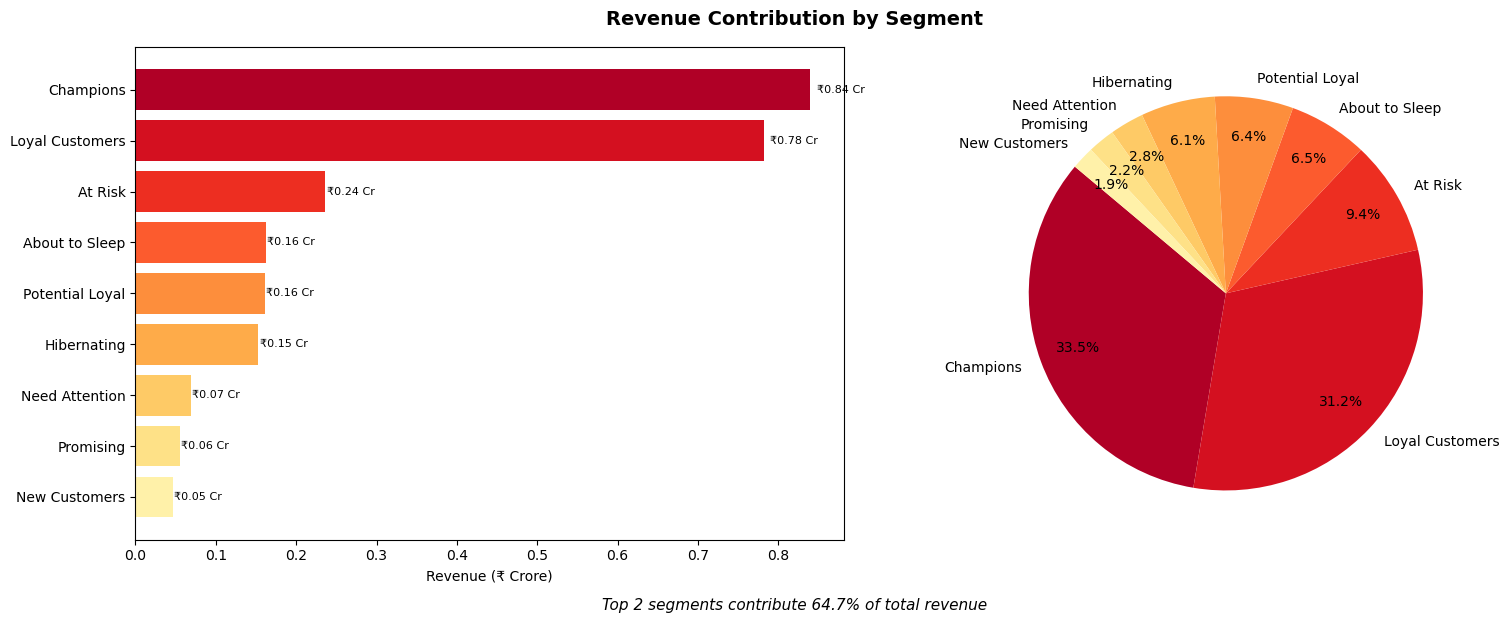


── Revenue Table ──
        Segment  Revenue_Cr  Revenue_Pct  Customer_Count  Revenue_per_Cust
      Champions    0.839166    33.472653              34     246813.538235
Loyal Customers    0.782039    31.193955              50     156407.725800
        At Risk    0.236414     9.430099              31      76262.729032
 About to Sleep    0.162595     6.485580              38      42788.097632
Potential Loyal    0.161036     6.423388              27      59642.821852
    Hibernating    0.152927     6.099970              37      41331.748108
 Need Attention    0.069795     2.783977              22      31724.936364
      Promising    0.055793     2.225458              14      39851.900714
  New Customers    0.047255     1.884920              12      39379.421667


In [58]:
rev = (rfm_df.groupby('Segment')
             .agg(Total_Revenue=('Monetary','sum'), Customer_Count=('customer_id','count'))
             .reset_index())
rev['Revenue_Cr']       = rev['Total_Revenue'] / 1e7
rev['Revenue_Pct']      = rev['Total_Revenue'] / rev['Total_Revenue'].sum() * 100
rev['Revenue_per_Cust'] = rev['Total_Revenue'] / rev['Customer_Count']
rev = rev.sort_values('Total_Revenue', ascending=False)

palette = plt.cm.YlOrRd_r(np.linspace(0.1, 0.9, len(rev)))
seg_c   = dict(zip(rev['Segment'], palette))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue Contribution by Segment', fontsize=14, fontweight='bold')

bars = axes[0].barh(rev['Segment'], rev['Revenue_Cr'],
                    color=[seg_c[s] for s in rev['Segment']])
axes[0].invert_yaxis(); axes[0].set_xlabel('Revenue (₹ Crore)')
for bar, val in zip(bars, rev['Revenue_Cr']):
    axes[0].text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                 f'₹{val:.2f} Cr', va='center', fontsize=8)

axes[1].pie(rev['Total_Revenue'], labels=rev['Segment'],
            colors=[seg_c[s] for s in rev['Segment']],
            autopct='%1.1f%%', pctdistance=0.80, startangle=140)

top2_pct = rev['Revenue_Pct'].iloc[:2].sum()
fig.text(0.5, -0.02, f'Top 2 segments contribute {top2_pct:.1f}% of total revenue',
         ha='center', fontsize=11, style='italic')

plt.tight_layout()
plt.show()
print("\n── Revenue Table ──")
print(rev[['Segment','Revenue_Cr','Revenue_Pct','Customer_Count','Revenue_per_Cust']].to_string(index=False))

Recency Deep Dive

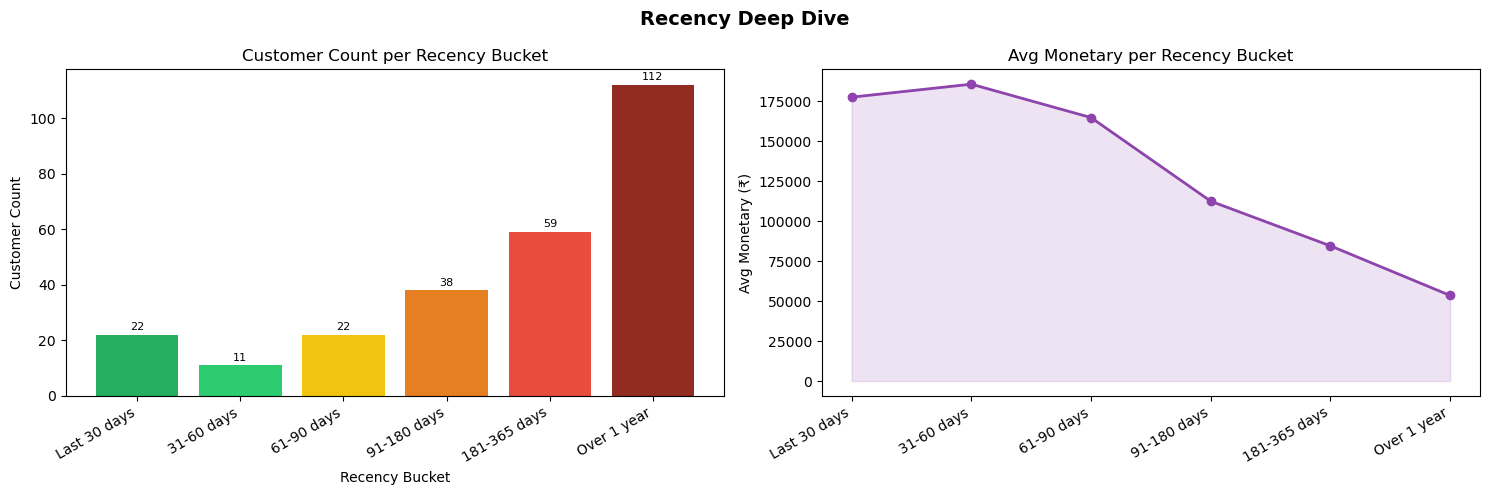


── Recency Bucket Summary ──
Recency_Bucket  Customer_Count  Avg_Monetary  Avg_Frequency       Pct
  Last 30 days              22 177390.407273       5.000000  8.333333
    31-60 days              11 185514.156364       4.909091  4.166667
    61-90 days              22 164639.738182       4.090909  8.333333
   91-180 days              38 112392.623421       2.894737 14.393939
  181-365 days              59  84490.821017       2.491525 22.348485
   Over 1 year             112  53495.565625       1.375000 42.424242

Active (≤90 days) : 55  |  Lapsing (>90 days): 209


In [59]:
bins   = [0, 30, 60, 90, 180, 365, float('inf')]
labels = ['Last 30 days','31-60 days','61-90 days','91-180 days','181-365 days','Over 1 year']

rfm_df['Recency_Bucket'] = pd.cut(rfm_df['Recency'], bins=bins, labels=labels, right=True)

rec_grp = (rfm_df.groupby('Recency_Bucket', observed=True)
                 .agg(Customer_Count=('customer_id','count'),
                      Avg_Monetary=('Monetary','mean'),
                      Avg_Frequency=('Frequency','mean'))
                 .reset_index())
rec_grp['Pct'] = rec_grp['Customer_Count'] / rec_grp['Customer_Count'].sum() * 100

gradient = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#922b21']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Recency Deep Dive', fontsize=14, fontweight='bold')

bars = axes[0].bar(rec_grp['Recency_Bucket'].astype(str), rec_grp['Customer_Count'], color=gradient)
axes[0].set_xlabel('Recency Bucket'); axes[0].set_ylabel('Customer Count')
axes[0].set_title('Customer Count per Recency Bucket')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')
for bar in bars:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

axes[1].plot(rec_grp['Recency_Bucket'].astype(str), rec_grp['Avg_Monetary'],
             color='#8e44ad', marker='o', linewidth=2)
axes[1].fill_between(range(len(rec_grp)), rec_grp['Avg_Monetary'], alpha=0.15, color='#8e44ad')
axes[1].set_xticks(range(len(rec_grp)))
axes[1].set_xticklabels(rec_grp['Recency_Bucket'].astype(str), rotation=30, ha='right')
axes[1].set_ylabel('Avg Monetary (₹)'); axes[1].set_title('Avg Monetary per Recency Bucket')

plt.tight_layout()
plt.show()
print("\n── Recency Bucket Summary ──")
print(rec_grp.to_string(index=False))

active  = int(rec_grp.loc[rec_grp['Recency_Bucket'].isin(
    ['Last 30 days','31-60 days','61-90 days']), 'Customer_Count'].sum())
lapsing = int(rec_grp['Customer_Count'].sum()) - active
print(f"\nActive (≤90 days) : {active:,}  |  Lapsing (>90 days): {lapsing:,}")

RFM Heatmap

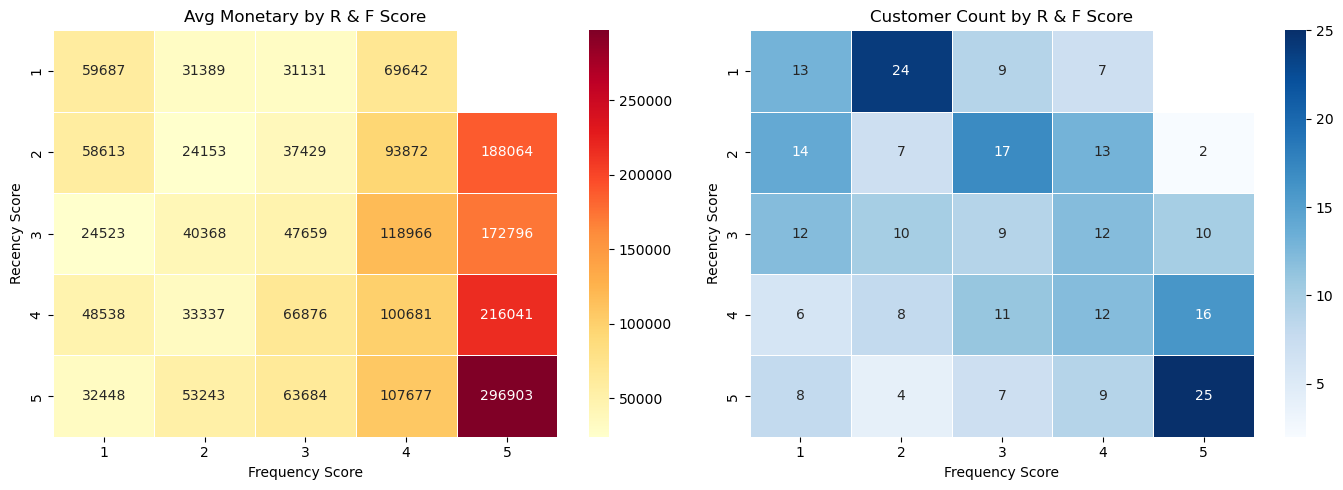


Highest Avg Monetary → R_score=5, F_score=5  (₹296,903)


In [60]:
pivot_monetary = rfm_df.pivot_table(
    index='R_score', columns='F_score', values='Monetary', aggfunc='mean')
pivot_count = rfm_df.pivot_table(
    index='R_score', columns='F_score', values='customer_id', aggfunc='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_monetary, ax=axes[0], annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5)
axes[0].set_title('Avg Monetary by R & F Score')
axes[0].set_xlabel('Frequency Score'); axes[0].set_ylabel('Recency Score')

sns.heatmap(pivot_count, ax=axes[1], annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5)
axes[1].set_title('Customer Count by R & F Score')
axes[1].set_xlabel('Frequency Score'); axes[1].set_ylabel('Recency Score')

plt.tight_layout()
plt.show()

best = pivot_monetary.stack().idxmax()
print(f"\nHighest Avg Monetary → R_score={best[0]}, F_score={best[1]}"
      f"  (₹{pivot_monetary.loc[best[0], best[1]]:,.0f})")

Segment Opportunity Analysis

In [61]:
cols = ['customer_name', 'customer_state', 'Recency', 'Frequency', 'Monetary', 'Segment']

groups = {
    'Win-Back Candidates'      : (rfm_df['Segment'].isin(['At Risk','Cannot Lose Them']),   'Monetary'),
    'Upsell Candidates'        : (rfm_df['Segment'].isin(['Potential Loyal','Promising']),   'Frequency'),
    'Reward Candidates'        : (rfm_df['Segment'].isin(['Champions','Loyal Customers']),   'Monetary'),
    'Re-engagement Candidates' : (rfm_df['Segment'].isin(['Hibernating','Lost']),            'Monetary'),
}

for group_name, (mask, sort_col) in groups.items():
    subset = rfm_df[mask].sort_values(sort_col, ascending=False).head(20)
    print(f"\n{'='*60}")
    print(f"  {group_name}  (n={mask.sum():,})")
    print('='*60)
    print(subset[cols].to_string(index=False))


  Win-Back Candidates  (n=31)
 customer_name customer_state  Recency  Frequency  Monetary Segment
   Arjun Kumar         Punjab      549          7 223168.00 At Risk
    Kiran Shah     Tamil Nadu      567          2 192077.74 At Risk
    Mohan Iyer  Uttar Pradesh      428          4 152960.19 At Risk
   Aarav Kumar      Telangana      604          2 139691.78 At Risk
   Nikhil Shah         Punjab      465          3 138048.23 At Risk
  Pankaj Joshi        Gujarat      432          4 128756.81 At Risk
    Meera Shah      Karnataka      771          4 126847.03 At Risk
   Arjun Naidu      Telangana      434          2 108140.03 At Risk
   Ananya Nair          Bihar      391          2  98306.75 At Risk
  Nisha Mishra Madhya Pradesh      997          1  95185.46 At Risk
Tarun Malhotra Madhya Pradesh      441          3  94968.52 At Risk
    Mohan Iyer         Kerala      460          2  94702.91 At Risk
  Sneha Pillai      Telangana      750          2  85101.07 At Risk
   Aarav Patel   

Geographic Distribution of RFM Segments

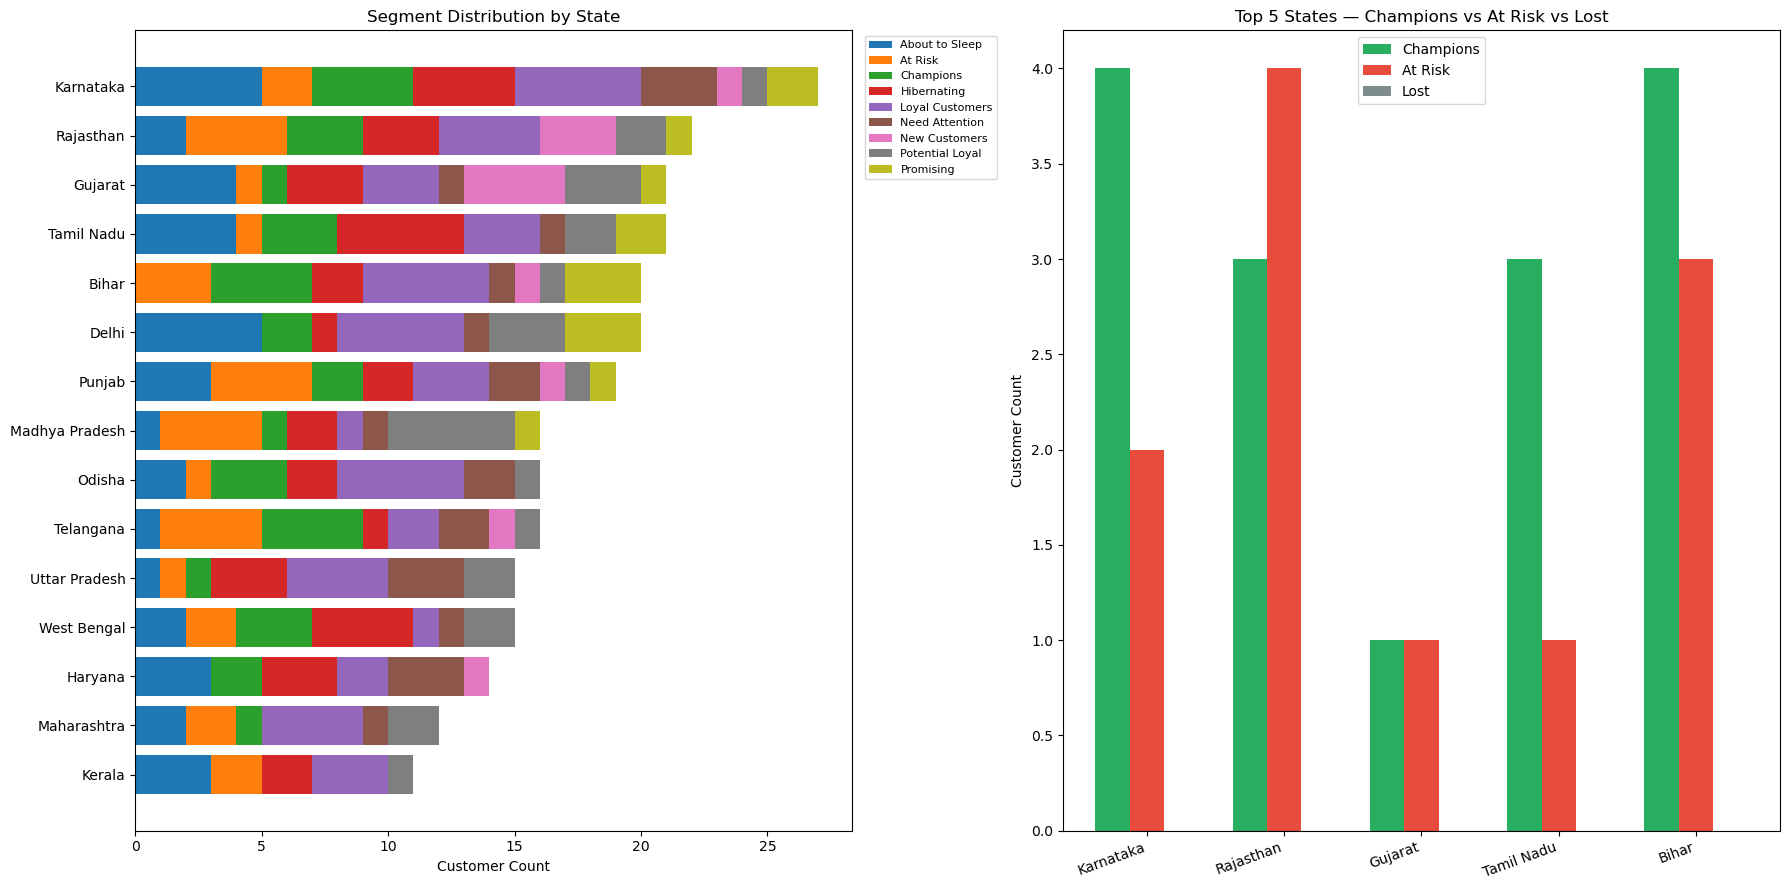


── State × Segment Pivot (top 10 states) ──
Segment         About to Sleep  At Risk  Champions  Hibernating  Loyal Customers  Need Attention  New Customers  Potential Loyal  Promising  Total
customer_state                                                                                                                                    
Karnataka                  5.0      2.0        4.0          4.0              5.0             3.0            1.0              1.0        2.0   27.0
Rajasthan                  2.0      4.0        3.0          3.0              4.0             0.0            3.0              2.0        1.0   22.0
Gujarat                    4.0      1.0        1.0          3.0              3.0             1.0            4.0              3.0        1.0   21.0
Tamil Nadu                 4.0      1.0        3.0          5.0              3.0             1.0            0.0              2.0        2.0   21.0
Bihar                      0.0      3.0        4.0          2.0          

In [62]:
geo = (rfm_df.groupby(['customer_state','Segment'])
             .size().reset_index(name='Count'))

pivot = (geo.pivot_table(index='customer_state', columns='Segment',
                         values='Count', aggfunc='sum')
            .fillna(0))
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)

segments = [c for c in pivot.columns if c != 'Total']
palette  = plt.cm.tab10.colors
seg_c    = {s: palette[i % 10] for i, s in enumerate(segments)}

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

bottom = np.zeros(len(pivot))
for seg in segments:
    if seg in pivot.columns:
        vals = pivot[seg].values
        axes[0].barh(pivot.index, vals, left=bottom, color=seg_c[seg], label=seg)
        bottom += vals
axes[0].invert_yaxis()
axes[0].set_xlabel('Customer Count')
axes[0].set_title('Segment Distribution by State')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

top5    = pivot.head(5).index.tolist()
top5_df = rfm_df[rfm_df['customer_state'].isin(top5)]
key_segs = ['Champions','At Risk','Lost']
key_clrs = {'Champions':'#27ae60','At Risk':'#e74c3c','Lost':'#7f8c8d'}
x, width = np.arange(len(top5)), 0.25

for i, seg in enumerate(key_segs):
    counts = [top5_df[(top5_df['customer_state']==s) &
                      (top5_df['Segment']==seg)].shape[0] for s in top5]
    axes[1].bar(x + i*width, counts, width, label=seg, color=key_clrs[seg])

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(top5, rotation=20, ha='right')
axes[1].set_title('Top 5 States — Champions vs At Risk vs Lost')
axes[1].set_ylabel('Customer Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print("\n── State × Segment Pivot (top 10 states) ──")
print(pivot.head(10).to_string())

Export RFM Data for Power BI

In [63]:
clv_bins   = [0, 500, 2000, 10000, float('inf')]
clv_labels = ['Low','Medium','High','Premium']
rfm_df['clv_tier'] = pd.cut(rfm_df['Monetary'], bins=clv_bins,
                             labels=clv_labels, right=False)

table1_cols = [
    'customer_id','customer_name','customer_city','customer_state',
    'Recency','Frequency','Monetary',
    'R_score','F_score','M_score','RFM_Score','RFM_Total',
    'Segment','clv_tier'
]
table1 = rfm_df[table1_cols].copy()

total_rev = rfm_df['Monetary'].sum()
table2 = (rfm_df.groupby('Segment')
                .agg(customer_count=('customer_id','count'),
                     avg_recency=('Recency','mean'),
                     avg_frequency=('Frequency','mean'),
                     avg_monetary=('Monetary','mean'),
                     total_revenue=('Monetary','sum'),
                     avg_rfm_total=('RFM_Total','mean'))
                .reset_index())
table2['revenue_pct'] = table2['total_revenue'] / total_rev * 100

table1.to_csv('rfm_customer_segments_powerbi.csv', index=False)
table2.to_csv('rfm_segment_summary_powerbi.csv',   index=False)

print(f"rfm_customer_segments_powerbi.csv → {len(table1):,} rows")
print(table1.head(5).to_string(index=False))
print(f"\nrfm_segment_summary_powerbi.csv → {len(table2):,} rows")
print(table2.to_string(index=False))

rfm_customer_segments_powerbi.csv → 265 rows
customer_id customer_name customer_city customer_state  Recency  Frequency  Monetary  R_score  F_score  M_score RFM_Score  RFM_Total         Segment clv_tier
  CUST00081  Arjun Pandey        Rohini          Delhi       72          2  44664.44        5        3        3       533         11 Potential Loyal  Premium
  CUST00169  Varun Pillai        Mumbai    Maharashtra      396          1  42951.37        2        1        2       212          5  About to Sleep  Premium
  CUST00298    Ravi Patel        Howrah    West Bengal      150          8 305860.39        4        5        5       455         14 Loyal Customers  Premium
  CUST00320 Suresh Sharma    Coimbatore     Tamil Nadu      307          2  57609.10        3        3        3       333          9 Potential Loyal  Premium
  CUST00379     Kiran Das         Surat        Gujarat      142          2  43790.76        4        3        3       433         10 Potential Loyal  Premium

rfm_se